# DNA Methylation Analysis with `cytozip`

CLI walkthrough using 9 mouse 3C-seq cells shipped under
`cytozip_example_data/bam/`. All steps are demonstrated as shell
commands (`! czip ...`); benchmark results produced offline by the
scripts under `tests/` are loaded and rendered as tables.

1. Setup + reference `.cz`
2. BAM → `.cz`  (`czip bam_to_cz`)
3. ALLC → `.cz` (`czip allc2cz`) + benchmark table (BAM→ALLC vs BAM→CZ, ALLC→CZ)
4. `view` / `query` (local) + benchmark table (tabix vs czip query)
5. `view` / `query` a remote `.cz`
6. `catcz` + `merge_cz`
7. `cz_to_anndata`

Benchmark
```python
python tests/benchmark_bam_to_cz.py  -j 20
python tests/benchmark_allc_to_cz.py -j 20
python tests/benchmark_query.py
```

In [1]:
import os,sys
import pandas as pd
os.chdir(os.path.expanduser("~/Projects/Github/cytozip/cytozip_example_data"))

## 1. Build the reference `.cz`

The reference holds the genome-wide `(chrom, pos, strand, context)`
axis. Per-cell `.cz` then store only `mc`/`cov` and reuse the
reference's positions, cutting per-cell size by ~5×.


In [80]:
!czip build_ref --help

usage: czip build_ref [-h] -g GENOME [-O OUTPUT] [-p PATTERN] [-j JOBS]
                      [--keep_temp] [--no_delta]

options:
  -h, --help            show this help message and exit
  -g GENOME, --genome GENOME
                        reference genome FASTA (default: None)
  -O OUTPUT, --output OUTPUT
                        output .cz file (default: hg38_allc.cz)
  -p PATTERN, --pattern PATTERN
                        nucleotide pattern (default: C)
  -j JOBS, --jobs JOBS  number of parallel processes (CPUs) (default: 12)
  --keep_temp           keep temp directory (default: False)
  --no_delta            disable DELTA encoding on the pos column (default: on,
                        gives ~3x smaller reference files with mild query
                        overhead) (default: False)


In [3]:
!time czip build_ref -g ~/Ref/mm10/mm10_ucsc_with_chrL.fa -O output/mm10_with_chrL.allc.cz -j 20

2026-04-26 13:18:07.418 | DEBUG    | cytozip.allc:WriteC:60 - chr1
2026-04-26 13:18:08.102 | DEBUG    | cytozip.allc:WriteC:60 - chr10
2026-04-26 13:18:08.772 | DEBUG    | cytozip.allc:WriteC:60 - chr11
2026-04-26 13:18:09.438 | DEBUG    | cytozip.allc:WriteC:60 - chr12
2026-04-26 13:18:10.071 | DEBUG    | cytozip.allc:WriteC:60 - chr13
2026-04-26 13:18:10.770 | DEBUG    | cytozip.allc:WriteC:60 - chr14
2026-04-26 13:18:11.307 | DEBUG    | cytozip.allc:WriteC:60 - chr15
2026-04-26 13:18:11.827 | DEBUG    | cytozip.allc:WriteC:60 - chr16
2026-04-26 13:18:12.356 | DEBUG    | cytozip.allc:WriteC:60 - chr17
2026-04-26 13:18:12.875 | DEBUG    | cytozip.allc:WriteC:60 - chr18
2026-04-26 13:18:13.151 | DEBUG    | cytozip.allc:WriteC:60 - chr1_GL456210_random
2026-04-26 13:18:13.153 | DEBUG    | cytozip.allc:WriteC:60 - chr1_GL456211_random
2026-04-26 13:18:13.155 | DEBUG    | cytozip.allc:WriteC:60 - chr19
2026-04-26 13:18:13.156 | DEBUG    | cytozip.allc:WriteC:60 - chr1_GL456212_random
2026

In [26]:
!czip header -I output/mm10_with_chrL.allc.cz

magic  :  b'CZIP'
version  :  0.3
total_size  :  1324830611
message  :  /home/x-wding2/Ref/mm10/mm10_ucsc_with_chrL.fa
formats  :  ['Q', 'c', '3s']
columns  :  ['pos', 'strand', 'context']
sort_col  :  0
delta_cols  :  [0]
chunk_dims  :  ['chrom']
header_size  :  102


In [27]:
! czip view -I output/mm10_with_chrL.allc.cz --show_dims 0 | head

chrom	pos	strand	context
chr1	3000003	+	CTG
chr1	3000005	-	CAG
chr1	3000009	+	CTA
chr1	3000016	-	CAA
chr1	3000018	-	CAC
chr1	3000019	-	CCA
chr1	3000023	+	CTT
chr1	3000027	-	CAA
chr1	3000029	-	CTC


In [28]:
! czip summary -I output/mm10_with_chrL.allc.cz | head

chrom	chunk_start_offset	chunk_size	chunk_tail_offset	chunk_nblocks	chunk_nrows
chr1	102	95328851	95386814	3615	78962721
chr10	95386814	63310564	158735944	2409	52609184
chr11	158735944	60770669	219544747	2382	52027265
chr12	219544747	58457323	278037836	2234	48799752
chr13	278037836	58621213	336694783	2232	48750883
chr14	336694783	60350467	397081896	2289	49987736
chr15	397081896	50425550	447538412	1934	42230765
chr16	447538412	47066788	494633718	1781	38899643
chr17	494633718	46270276	540932704	1793	39153472


## 3. BAM → `.cz`

Convert a position-sorted BAM directly to `.cz` (no intermediate ALLC
text). The output has only `mc` / `cov` because we pass a reference.


In [81]:
!czip bam_to_cz --help

usage: czip bam_to_cz [-h] -I INPUT -g GENOME [-O OUTPUT]
                      [--num_upstr_bases NUM_UPSTR_BASES]
                      [--num_downstr_bases NUM_DOWNSTR_BASES]
                      [--min_mapq MIN_MAPQ]
                      [--min_base_quality MIN_BASE_QUALITY] [-c BATCH_SIZE]
                      [--convert_bam_strandness] [--save_count_df]
                      [--mode {full,pos_mc_cov,mc_cov}]
                      [--count_fmt {B,H,I,Q}] [-r REFERENCE]

options:
  -h, --help            show this help message and exit
  -I INPUT, --input INPUT
                        input position-sorted BAM (bismark/hisat-3n) (default:
                        None)
  -g GENOME, --genome GENOME
                        indexed reference fasta (.fai required) (default:
                        None)
  -O OUTPUT, --output OUTPUT
                        output .cz path (default: <bam_stem>.cz) (default:
                        None)
  --num_upstr_bases NUM_UPSTR_BASES
              

In [2]:
! time czip bam_to_cz -I bam/FC_M_P12b_3C_2-5-M17-N10.hisat3n_dna.all_reads.deduped.bam \
     --genome ~/Ref/mm10/mm10_ucsc_with_chrL.fa -O output/cz/FC_M_P12b_3C_2-5-M17-N10.cz \
     --mode mc_cov --count_fmt B --reference output/mm10_with_chrL.allc.cz

/home/x-wding2/Software/conda/m3c/lib/python3.10/site-packages/cytozip/bam.py:726: UserWarning: mc/cov value exceeds count_fmt='B' max (255); clipping. Consider count_fmt='H' for bulk/high-coverage data.
  _handle_site(

real	1m49.128s
user	1m37.383s
sys	0m8.018s


In [31]:
#bam to allc
from ALLCools._bam_to_allc import bam_to_allc
%time bam_to_allc(bam_path="bam/FC_M_P12b_3C_2-5-M17-N10.hisat3n_dna.all_reads.deduped.bam", \
                  reference_fasta=os.path.expanduser("~/Ref/mm10/mm10_ucsc_with_chrL.fa"), \
                  output_path="output/allc/FC_M_P12b_3C_2-5-M17-N10.allc.tsv.gz", \
                  cpu=1,num_upstr_bases=0, num_downstr_bases=2, \
                  min_mapq=10, min_base_quality=20)

CPU times: user 2min 58s, sys: 7.24 s, total: 3min 5s
Wall time: 3min 21s


,mc,cov,mc_rate,genome_cov
CTT,2135943,4141584,0.515731,0.066954
CTA,1326142,2710024,0.489347,0.066954
CAA,1716819,3719684,0.461550,0.066954
CCA,1680893,3521141,0.477372,0.066954
CAC,1501706,3073867,0.488540,0.066954
CAG,1929009,4047201,0.476628,0.066954
CTG,2026603,4048731,0.500553,0.066954
CCT,1706829,3381003,0.504829,0.066954
CCC,1108042,2312639,0.479124,0.066954
CAT,1831117,3671417,0.498749,0.066954


### BAM → `.cz` benchmark vs ALLCools

Produced by `tests/benchmark_bam_to_cz.py -j 9`. ALLCools writes a
gzipped TSV (`.allc.tsv.gz`); cytozip writes a chunked, columnar
zstd-compressed `.cz`.


In [2]:
import pandas as pd
bam_bench = pd.read_csv('output/bam_benchmark/bam_benchmark.tsv', sep='\t')
bam_bench.round(2)

,cell,bam_size_mb,n_reads,allc_wall_s,allc_rss_mb,allc_size_mb,allc_cached,cz_wall_s,cz_rss_mb,cz_size_mb,speedup,size_ratio
0,FC_E17b_3C_5-5-I24-A21,685.99,7330382,1566.53,571.61,442.62,True,261.78,935.12,78.89,5.98,0.18
1,FC_M_E15a_3C_1-1-I5-B1,177.37,1787812,728.97,571.79,102.53,True,84.16,927.48,22.41,8.66,0.22
2,FC_M_P12b_3C_2-5-M17-N10,239.89,2307326,884.07,577.01,143.12,True,102.93,926.09,29.85,8.59,0.21
3,FC_M_P3b_3C_6-6-J3-P24,147.36,1395949,628.37,573.83,85.71,True,74.58,929.74,19.52,8.43,0.23
4,FC_M_P6a_3C_7-3-K21-P5,89.76,938870,412.18,574.35,48.84,True,56.10,942.63,12.32,7.35,0.25
5,FC_M_P9B_3C_6-2-F6-O4,32.28,342778,245.17,572.93,17.61,True,40.59,926.66,6.15,6.04,0.35
6,FC_P0b_3C_5-1-I24-J14,485.51,5028030,1385.09,574.75,285.50,True,174.42,923.10,52.72,7.94,0.18
7,FC_P13a_3C_7-1-A11-O1,260.71,2588754,949.58,571.56,155.84,True,108.78,926.09,31.47,8.73,0.20
8,FC_P28a_3C_2-1-E5-N14,186.32,1908846,803.77,574.15,112.95,True,87.11,927.01,24.11,9.23,0.21


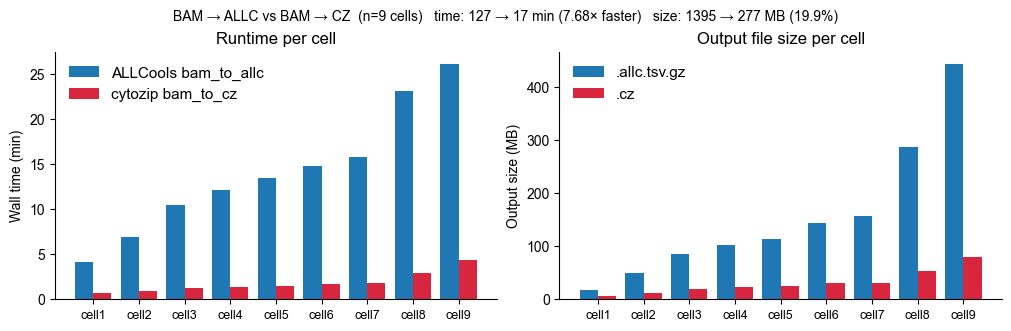

In [7]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'

df = bam_bench.sort_values('n_reads').reset_index(drop=True)
labels = [f'cell{i+1}' for i in range(len(df))]
x = np.arange(len(df))
w = 0.4
c_allc, c_cz = '#1f77b4', '#d7263d'

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), constrained_layout=True)

ax = axes[0]
ax.bar(x - w/2, df['allc_wall_s'] / 60, w, label='ALLCools bam_to_allc', color=c_allc)
ax.bar(x + w/2, df['cz_wall_s']  / 60, w, label='cytozip bam_to_cz',   color=c_cz)
ax.set_ylabel('Wall time (min)')
ax.set_title('Runtime per cell')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0, fontsize=9)
ax.legend(frameon=False, fontsize=11)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)

ax = axes[1]
ax.bar(x - w/2, df['allc_size_mb'], w, label='.allc.tsv.gz', color=c_allc)
ax.bar(x + w/2, df['cz_size_mb'],   w, label='.cz',          color=c_cz)
ax.set_ylabel('Output size (MB)')
ax.set_title('Output file size per cell')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0, fontsize=9)
ax.legend(frameon=False, fontsize=11)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)

tot_allc_t, tot_cz_t = df['allc_wall_s'].sum() / 60, df['cz_wall_s'].sum() / 60
tot_allc_s, tot_cz_s = df['allc_size_mb'].sum(),   df['cz_size_mb'].sum()
fig.suptitle(
    f'BAM → ALLC vs BAM → CZ  (n={len(df)} cells)   '
    f'time: {tot_allc_t:.0f} → {tot_cz_t:.0f} min ({tot_allc_t/tot_cz_t:.2f}× faster)   '
    f'size: {tot_allc_s:.0f} → {tot_cz_s:.0f} MB ({tot_cz_s/tot_allc_s*100:.1f}%)',
    fontsize=10,
)

fig.savefig('output/bam_benchmark/bam_benchmark.pdf', bbox_inches='tight')
plt.show()


In [3]:
!cat output/bam_benchmark/bam_benchmark.txt

cytozip bam_to_cz  vs  ALLCools bam_to_allc
reference FASTA : /home/x-wding2/Ref/mm10/mm10_ucsc_with_chrL.fa
reference .cz   : /anvil/projects/x-mcb130189/Wubin/Github/cytozip/cytozip_example_data/output/mm10_with_chrL.allc.cz
BAMs            : 9   total reads = 23,628,747
ALLCools cached : 9/9 (timing reused from disk)

ALLCools : time=  7603.7 s   peak_rss=  577.0 MB   size=  1394.7 MB
cytozip  : time=   990.4 s   peak_rss=  942.6 MB   size=   277.5 MB

speedup (allc / cz time)  =  7.68x
compression (cz / allc)   =  19.9%


## 4. ALLC → `.cz`

Pack an existing `.allc.tsv.gz` into `.cz`. Two layouts:

In [3]:
! czip allc2cz --help

usage: czip allc2cz [-h] -I INPUT -O OUTPUT [-r REFERENCE]
                    [--missing_value MISSING_VALUE] [-F FORMATS] [-C COLUMNS]
                    [-D CHUNK_DIMS] [-u USECOLS] [--ref_pos_col REF_POS_COL]
                    [--allc_pos_col ALLC_POS_COL] [-s SEP]
                    [--chrom_order CHROM_ORDER] [-c BATCH_SIZE]
                    [--sort_col SORT_COL] [--delta_cols DELTA_COLS] [-j JOBS]
                    [--pattern PATTERN] [--no_skip_existing]

options:
  -h, --help            show this help message and exit
  -I INPUT, --input INPUT
                        input allc.tsv.gz, OR a directory containing many
                        allc.tsv.gz (batch mode: --output must be a directory)
                        (default: None)
  -O OUTPUT, --output OUTPUT
                        output .cz file (single-file), or output directory
                        (batch mode) (default: None)
  -r REFERENCE, --reference REFERENCE
                        reference .cz file (

In [10]:
# Standalone (positions inside the .cz)
! time czip allc2cz -I output/allc/FC_M_P12b_3C_2-5-M17-N10.allc.tsv.gz \
      -O output/allc/FC_M_P12b_3C_2-5-M17-N10.with_pos.cz \
      -F Q,B,B -C pos,mc,cov -u 1,4,5

2026-04-26 23:48:10.231 | INFO     | cytozip.allc:allc2cz:261 - /anvil/projects/x-mcb130189/Wubin/Github/cytozip/cytozip_example_data/output/allc/FC_M_P12b_3C_2-5-M17-N10.allc.tsv.gz

real	0m22.260s
user	0m20.172s
sys	0m1.776s


In [11]:
# Reference-aligned (positions come from the reference .cz)
! time czip allc2cz -I output/allc/FC_M_P12b_3C_2-5-M17-N10.allc.tsv.gz \
      -O output/allc/FC_M_P12b_3C_2-5-M17-N10.cz \
      -r output/mm10_with_chrL.allc.cz

2026-04-26 23:49:10.687 | INFO     | cytozip.allc:allc2cz:261 - /anvil/projects/x-mcb130189/Wubin/Github/cytozip/cytozip_example_data/output/allc/FC_M_P12b_3C_2-5-M17-N10.allc.tsv.gz

real	0m50.041s
user	0m41.189s
sys	0m8.606s


In [12]:
! ls output/allc/FC_M_P12b_3C_2-5-M17-N10* -sh

 512 output/allc/FC_M_P12b_3C_2-5-M17-N10.allc.bench.json
137M output/allc/FC_M_P12b_3C_2-5-M17-N10.allc.tsv.gz
1.5M output/allc/FC_M_P12b_3C_2-5-M17-N10.allc.tsv.gz.tbi
 29M output/allc/FC_M_P12b_3C_2-5-M17-N10.cz
 42M output/allc/FC_M_P12b_3C_2-5-M17-N10.with_pos.cz


## 5. `view` and `query`

`czip view` streams an entire dimension (e.g. one chrom). `czip query`
pulls a region. Both can use `-r REFERENCE` to expand reference-aligned
files into full ALLC-style records (chrom / pos / context / mc / cov).


In [13]:
! czip view -I output/allc/FC_M_P12b_3C_2-5-M17-N10.cz \
    -r output/mm10_with_chrL.allc.cz --show_dims 0 | awk '$6>0' | head

chrom	pos	strand	context	mc	cov
chr1	3005823	+	CTT	0	1
chr1	3005826	+	CTA	0	1
chr1	3005836	+	CAA	0	1
chr1	3005840	+	CCA	0	1
chr1	3005841	+	CAC	0	1
chr1	3005843	+	CCA	0	1
chr1	3005844	+	CAC	0	1
chr1	3005846	+	CAA	1	1
chr1	3005850	+	CCA	0	1


In [14]:
! tabix output/allc/FC_M_P12b_3C_2-5-M17-N10.allc.tsv.gz chr9:3000294-3005294 | head

chr9	3000294	-	CAT	15	23	1
chr9	3000296	+	CCT	51	62	1
chr9	3000297	+	CTA	53	63	1
chr9	3000300	+	CAA	52	65	1
chr9	3000304	-	CAT	2	26	1
chr9	3000305	-	CCA	1	27	1
chr9	3000307	+	CAT	60	71	1
chr9	3000312	+	CTA	63	76	1
chr9	3000321	+	CCA	67	78	1
chr9	3000322	+	CAA	65	76	1
Failed to write to stdout: Broken pipe


In [15]:
! time czip query -I output/allc/FC_M_P12b_3C_2-5-M17-N10.cz \
    -r output/mm10_with_chrL.allc.cz -K chr9 -s 3000294 -e 3005294 | head

chrom	pos	strand	context	mc	cov
chr9	3000294	-	CAT	15	23
chr9	3000296	+	CCT	51	62
chr9	3000297	+	CTA	53	63
chr9	3000300	+	CAA	52	65
chr9	3000304	-	CAT	2	26
chr9	3000305	-	CCA	1	27
chr9	3000307	+	CAT	60	71
chr9	3000312	+	CTA	63	76
chr9	3000321	+	CCA	67	78

real	0m0.267s
user	0m0.143s
sys	0m0.091s


### Warm query: `query_numpy` vs `pytabix` across region sizes

`tests/benchmark_query.py` also runs a region-size scan: same chrom,
growing windows from 5 kb up to 50 Mb on one cell. `pytabix` per-call
time scales ~linearly with the number of records returned (every hit
is materialized as a Python tuple), whereas `Reader.query_numpy`
serves the same range out of an already-decoded `np.ndarray` via
`np.searchsorted`, so it stays roughly constant.


,size_bp,n_records,pytabix_mean,pytabix_std,qnumpy_mean,qnumpy_std,n_replicates
0,5000,52,0.0895,0.0043,0.0081,0.0003,10
1,50000,378,0.1621,0.0014,0.0081,0.0003,10
2,500000,2586,0.9992,0.0165,0.0087,0.0005,10
3,5000000,26169,12.4533,0.1214,0.0104,0.0005,10
4,50000000,260769,180.6150,2.0174,0.0272,0.0020,10


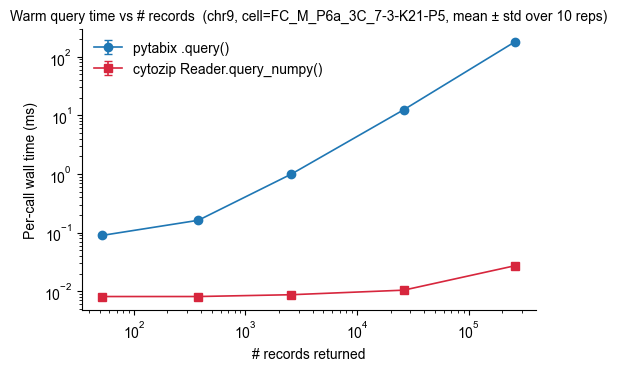

In [11]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'

scale = pd.read_csv('output/query_benchmark/query_scale_benchmark.tsv', sep='\t')

# Aggregate the 10 replicates per size: mean ± std (in ms).
agg = (scale
       .assign(pytabix_ms=scale['pytabix_time_s'] * 1e3,
               qnumpy_ms=scale['qnumpy_time_s'] * 1e3)
       .groupby(['size_bp', 'n_records'], as_index=False)
       .agg(pytabix_mean=('pytabix_ms', 'mean'),
            pytabix_std=('pytabix_ms', 'std'),
            qnumpy_mean=('qnumpy_ms', 'mean'),
            qnumpy_std=('qnumpy_ms', 'std'),
            n_replicates=('pytabix_ms', 'size'))
       .sort_values('size_bp')
       .reset_index(drop=True))
display(agg.round(4))

c_tb, c_qn = '#1f77b4', '#d7263d'

fig, ax = plt.subplots(figsize=(5.2, 3.6), constrained_layout=True)

ax.errorbar(agg['n_records'], agg['pytabix_mean'], yerr=agg['pytabix_std'],
            marker='o', color=c_tb, capsize=3, lw=1.2,
            label='pytabix .query()')
ax.errorbar(agg['n_records'], agg['qnumpy_mean'], yerr=agg['qnumpy_std'],
            marker='s', color=c_qn, capsize=3, lw=1.2,
            label='cytozip Reader.query_numpy()')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('# records returned')
ax.set_ylabel('Per-call wall time (ms)')
ax.set_title(f'Warm query time vs # records  '
             f'({scale.iloc[0]["chrom"]}, cell={scale.iloc[0]["cell"]}, '
             f'mean ± std over {agg["n_replicates"].iloc[0]} reps)',
             fontsize=10)
ax.legend(frameon=False, fontsize=10)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)

fig.savefig('output/query_benchmark/query_scale_benchmark.pdf', bbox_inches='tight')
plt.show()


### Correctness check: cytozip query vs pytabix

`benchmark_query.py` also compares the records returned by
`Reader.query_numpy` against `pytabix.query()` on each cell, in the
same `chr9:3000294-3005294` region. Two expected differences are
accounted for:

* **`truncated_ge256`** — rows where the original ALLC `mc` or `cov`
  is ≥ 256 and was saturated to 255 by `--count_fmt B` (uint8). These
  are not bugs.
* **`only_in_cz_zero`** — positions present in the reference-aligned
  `.cz` but absent from the ALLC text file because they had no
  coverage; their `(mc, cov)` are `(0, 0)`. Also expected.

`mismatched` (different non-truncated values) and `only_in_cz_covered`
(positions only in `.cz` that have non-zero coverage) should both be
**0** for a correct implementation.


In [12]:
corr = pd.read_csv('output/query_benchmark/query_correctness.tsv', sep='\t')
display(corr)
print(f"Total over {len(corr)} cells:  "
      f"truncated(>=256)={corr['truncated_ge256'].sum()}  "
      f"mismatched={corr['mismatched'].sum()}  "
      f"only_in_cz_covered={corr['only_in_cz_covered'].sum()}  "
      f"only_in_cz_zero={corr['only_in_cz_zero'].sum()}")


,cell,region,pytabix_n,cz_n,truncated_ge256,mismatched,only_in_cz_zero,only_in_cz_covered
0,FC_E17b_3C_5-5-I24-A21,chr9:3000294-3005294,1682,1758,237,0,76,0
1,FC_M_E15a_3C_1-1-I5-B1,chr9:3000294-3005294,1547,1758,44,0,211,0
2,FC_M_P12b_3C_2-5-M17-N10,chr9:3000294-3005294,1615,1758,119,0,143,0
3,FC_M_P3b_3C_6-6-J3-P24,chr9:3000294-3005294,1537,1758,51,0,221,0
4,FC_M_P6a_3C_7-3-K21-P5,chr9:3000294-3005294,1480,1758,11,0,278,0
5,FC_M_P9B_3C_6-2-F6-O4,chr9:3000294-3005294,1229,1758,0,0,529,0
6,FC_P0b_3C_5-1-I24-J14,chr9:3000294-3005294,1642,1758,176,0,116,0
7,FC_P13a_3C_7-1-A11-O1,chr9:3000294-3005294,1567,1758,105,0,191,0
8,FC_P28a_3C_2-1-E5-N14,chr9:3000294-3005294,1479,1758,78,0,279,0


Total over 9 cells:  truncated(>=256)=821  mismatched=0  only_in_cz_covered=0  only_in_cz_zero=2044


## 6. View / query a remote `.cz` (no download)

cytozip reads `.cz` files directly over HTTP Range requests when they
carry a chunk index. Below we query a remote `.cz` hosted on figshare —
only the needed chunks are fetched on-demand.


In [16]:
! czip header -I https://neomorph.salk.edu/ftp/bican/FC_M_P12b_3C_2-5-M17-N10.cz

magic  :  b'CZIP'
version  :  0.3
total_size  :  29849112
message  :  mm10_with_chrL.allc.cz
formats  :  ['B', 'B']
columns  :  ['mc', 'cov']
sort_col  :  None
delta_cols  :  []
chunk_dims  :  ['chrom']
header_size  :  61


In [17]:
# view a cz file (no coordinates were stored) alone
! czip view -I https://neomorph.salk.edu/ftp/bican/FC_M_P12b_3C_2-5-M17-N10.cz --show_dims 0 | head

chrom	mc	cov
chr1	0	0
chr1	0	0
chr1	0	0
chr1	0	0
chr1	0	0
chr1	0	0
chr1	0	0
chr1	0	0
chr1	0	0


In [18]:
# query remote .cz file with local reference .cz:
! time czip query -I https://neomorph.salk.edu/ftp/bican/FC_M_P12b_3C_2-5-M17-N10.cz \
    -r output/mm10_with_chrL.allc.cz -K chr9 \
    -s 3000294 -e 3005294 | head -n 5

chrom	pos	strand	context	mc	cov
chr9	3000294	-	CAT	15	23
chr9	3000296	+	CCT	51	62
chr9	3000297	+	CTA	53	63
chr9	3000300	+	CAA	52	65

real	0m1.080s
user	0m0.217s
sys	0m0.112s


In [19]:
# or both the cz and the reference can be accessed via HTTP(S) URLs, without downloading any files locally:
! time czip query -I https://neomorph.salk.edu/ftp/bican/FC_M_P12b_3C_2-5-M17-N10.cz \
    -r https://neomorph.salk.edu/ftp/bican/mm10_with_chrL.allc.cz \
    -K chr9 -s 3000294 -e 3005294 | head -n 5
# query 5000 bp of regions containing 1759 records

chrom	pos	strand	context	mc	cov
chr9	3000294	-	CAT	15	23
chr9	3000296	+	CCT	51	62
chr9	3000297	+	CTA	53	63
chr9	3000300	+	CAA	52	65

real	0m2.147s
user	0m0.242s
sys	0m0.129s


## 7. `catcz` and `merge_cz`

* `catcz` — concatenate per-cell `.cz` into one multi-cell `.cz` by
  adding a `cell_id` dimension.
* `merge_cz` — sum `mc` / `cov` across cells (pooled pseudobulk).


In [20]:
! ls output/cz/*.cz -sh

 76M output/cz/FC_E17b_3C_5-5-I24-A21.cz
 22M output/cz/FC_M_E15a_3C_1-1-I5-B1.cz
 29M output/cz/FC_M_P12b_3C_2-5-M17-N10.cz
 19M output/cz/FC_M_P3b_3C_6-6-J3-P24.cz
 12M output/cz/FC_M_P6a_3C_7-3-K21-P5.cz
6.0M output/cz/FC_M_P9B_3C_6-2-F6-O4.cz
 51M output/cz/FC_P0b_3C_5-1-I24-J14.cz
 31M output/cz/FC_P13a_3C_7-1-A11-O1.cz
 23M output/cz/FC_P28a_3C_2-1-E5-N14.cz


In [21]:
! time czip catcz -O output/all_cells.cz -I "output/cz/*.cz" --key_added cell_id -F B,B -C mc,cov


real	0m1.424s
user	0m0.206s
sys	0m0.613s


In [22]:
! czip header -I output/all_cells.cz

magic  :  b'CZIP'
version  :  0.3
total_size  :  277478530
message  :  
formats  :  ['B', 'B']
columns  :  ['mc', 'cov']
sort_col  :  None
delta_cols  :  []
chunk_dims  :  ['chrom', 'cell_id']
header_size  :  47


In [23]:
! czip summary -I output/all_cells.cz | head

chrom	cell_id	chunk_start_offset	chunk_size	chunk_tail_offset	chunk_nblocks	chunk_nrows
chr1	FC_E17b_3C_5-5-I24-A21	47	6002191	6007106	603	78962721
chr10	FC_E17b_3C_5-5-I24-A21	6007106	3999949	10010316	402	52609184
chr11	FC_E17b_3C_5-5-I24-A21	10010316	3835747	13849284	397	52027265
chr12	FC_E17b_3C_5-5-I24-A21	13849284	3618595	17470908	373	48799752
chr13	FC_E17b_3C_5-5-I24-A21	17470908	3703795	21177724	372	48750883
chr14	FC_E17b_3C_5-5-I24-A21	21177724	3678031	24858856	382	49987736
chr15	FC_E17b_3C_5-5-I24-A21	24858856	3173077	28034562	323	42230765
chr16	FC_E17b_3C_5-5-I24-A21	28034562	2939286	30976269	297	38899643
chr17	FC_E17b_3C_5-5-I24-A21	30976269	2877415	33856121	299	39153472


In [24]:
# merge 9 single-cell .cz files into a pseudobulk .cz file, summing the mc and cov values across all cells:
! time czip merge_cz -i output/cz -O output/pseudobulk.cz \
    -r output/mm10_with_chrL.allc.cz -F H,H -j 20

2026-04-26 23:52:18.431 | INFO     | cytozip.merge:merge_cz:492 - output/pseudobulk.cz
2026-04-26 23:52:25.244 | INFO     | cytozip.merge:_bg_rmtree:141 - Removing temp dir /anvil/projects/x-mcb130189/Wubin/Github/cytozip/cytozip_example_data/output/pseudobulk.cz.tmp (in background)

real	0m7.040s
user	1m32.465s
sys	0m4.578s


In [25]:
! czip view -I output/pseudobulk.cz --show_dims 0 \
    -r output/mm10_with_chrL.allc.cz | awk '$6 >10' | head

chrom	pos	strand	context	mc	cov
chr1	25520457	-	CAA	11	11
chr1	25520458	-	CCA	11	11
chr1	25520463	-	CAG	11	11
chr1	25520464	-	CCA	11	11
chr1	25520474	-	CAG	13	13
chr1	25520479	-	CGG	13	13
chr1	25520480	-	CCG	13	13
chr1	25520481	-	CCC	12	13
chr1	25520482	-	CCC	12	12


In [26]:
! czip query -I output/pseudobulk.cz \
    -r output/mm10_with_chrL.allc.cz -K chr1 -s 25520457 -e 25520482

chrom	pos	strand	context	mc	cov
chr1	25520457	-	CAA	11	11
chr1	25520458	-	CCA	11	11
chr1	25520459	+	CCC	2	10
chr1	25520460	+	CCT	2	10
chr1	25520461	+	CTG	0	10
chr1	25520463	-	CAG	11	11
chr1	25520464	-	CCA	11	11
chr1	25520465	+	CGT	7	9
chr1	25520466	-	CGC	7	7
chr1	25520469	+	CCC	1	10
chr1	25520470	+	CCC	0	10
chr1	25520471	+	CCT	0	10
chr1	25520472	+	CTG	1	10
chr1	25520474	-	CAG	13	13
chr1	25520477	+	CCG	0	9
chr1	25520478	+	CGG	5	10
chr1	25520479	-	CGG	13	13
chr1	25520480	-	CCG	13	13
chr1	25520481	-	CCC	12	13
chr1	25520482	-	CCC	12	12


In [27]:
! for file in `ls output/cz`; do echo ${file} && czip query -I output/cz/${file} -r output/mm10_with_chrL.allc.cz -K chr1 -s 25520457 -e 25520482; done;

FC_E17b_3C_5-5-I24-A21.cz
chrom	pos	strand	context	mc	cov
chr1	25520457	-	CAA	3	3
chr1	25520458	-	CCA	3	3
chr1	25520459	+	CCC	2	2
chr1	25520460	+	CCT	2	2
chr1	25520461	+	CTG	0	2
chr1	25520463	-	CAG	3	3
chr1	25520464	-	CCA	3	3
chr1	25520465	+	CGT	1	1
chr1	25520466	-	CGC	1	1
chr1	25520469	+	CCC	1	2
chr1	25520470	+	CCC	0	2
chr1	25520471	+	CCT	0	2
chr1	25520472	+	CTG	1	2
chr1	25520474	-	CAG	3	3
chr1	25520477	+	CCG	0	2
chr1	25520478	+	CGG	1	2
chr1	25520479	-	CGG	3	3
chr1	25520480	-	CCG	3	3
chr1	25520481	-	CCC	3	3
chr1	25520482	-	CCC	3	3
FC_M_E15a_3C_1-1-I5-B1.cz
chrom	pos	strand	context	mc	cov
chr1	25520457	-	CAA	1	1
chr1	25520458	-	CCA	1	1
chr1	25520459	+	CCC	0	1
chr1	25520460	+	CCT	0	1
chr1	25520461	+	CTG	0	1
chr1	25520463	-	CAG	1	1
chr1	25520464	-	CCA	1	1
chr1	25520465	+	CGT	0	1
chr1	25520466	-	CGC	1	1
chr1	25520469	+	CCC	0	1
chr1	25520470	+	CCC	0	1
chr1	25520471	+	CCT	0	1
chr1	25520472	+	CTG	0	1
chr1	25520474	-	CAG	2	2
chr1	25520477	+	CCG	0	0
chr1	25520478	+	CGG	0	1
chr1	25520479	-	CGG	

## 8. Build a cell × gene `AnnData`

`cytozip.features.cz_to_anndata` aggregates per-cell `.cz` files over
a feature interval set. When `features=` is a GTF path, cytozip
extracts one interval per gene, merges GENCODE records sharing a
symbol, and extends each interval by `flank_bp` (default 2 kb) on
both sides.


In [28]:
! time czip cz_to_anndata -I output/cz \
    -f /home/x-wding2/Ref/mm10/annotations/gencode.vM23.annotation.gtf \
    -O output/allcells.h5ad -r output/mm10_with_chrL.allc.cz -j 10


real	0m56.459s
user	3m6.523s
sys	2m6.136s


In [29]:
import anndata
adata=anndata.read_h5ad("output/allcells.h5ad")
adata

AnnData object with n_obs × n_vars = 9 × 55228
    obs: 'alpha', 'beta', 'prior_mean'
    var: 'chrom', 'start', 'end', 'gene_id', 'gene_name', 'gene_type', 'strand'
    uns: 'cytozip_score'
    layers: 'cov', 'mc'

In [30]:
adata.obs

,alpha,beta,prior_mean
FC_E17b_3C_5-5-I24-A21,16.552773,4.298903,0.793834
FC_M_E15a_3C_1-1-I5-B1,2.186242,2.139226,0.505435
FC_M_P12b_3C_2-5-M17-N10,2.995694,2.875796,0.510210
FC_M_P3b_3C_6-6-J3-P24,1.944698,1.912869,0.504125
FC_M_P6a_3C_7-3-K21-P5,1.220260,1.223016,0.499436
FC_M_P9B_3C_6-2-F6-O4,0.855686,0.833245,0.506644
FC_P0b_3C_5-1-I24-J14,5.303945,5.269817,0.501614
FC_P13a_3C_7-1-A11-O1,2.719091,2.712517,0.500605
FC_P28a_3C_2-1-E5-N14,2.280605,2.223951,0.506289


In [31]:
adata.var

,chrom,start,end,gene_id,gene_name,gene_type,strand
name,,,,,,,
0610005C13Rik,chr7,45565793,45577327,ENSMUSG00000109644.1,0610005C13Rik,lncRNA,-
0610006L08Rik,chr7,74816817,74855813,ENSMUSG00000108652.1,0610006L08Rik,lncRNA,-
0610009B22Rik,chr11,51683385,51690874,ENSMUSG00000007777.9,0610009B22Rik,protein_coding,-
0610009E02Rik,chr2,26443695,26461390,ENSMUSG00000086714.1,0610009E02Rik,lncRNA,+
0610009L18Rik,chr11,120346677,120353190,ENSMUSG00000043644.4,0610009L18Rik,lncRNA,+
...,...,...,...,...,...,...,...
n-R5s96,chr8,47717245,47721369,ENSMUSG00000064508.1,n-R5s96,rRNA,+
n-R5s97,chr8,47897181,47901294,ENSMUSG00000064519.1,n-R5s97,rRNA,+
n-R5s98,chr8,54864260,54868379,ENSMUSG00000084498.1,n-R5s98,rRNA,+


In [32]:
adata.to_df()

name,0610005C13Rik,0610006L08Rik,0610009B22Rik,0610009E02Rik,0610009L18Rik,0610010F05Rik,0610010K14Rik,0610012D04Rik,0610012G03Rik,0610025J13Rik,...,n-R5s90,n-R5s92,n-R5s93,n-R5s94,n-R5s95,n-R5s96,n-R5s97,n-R5s98,n-TSaga9,n-TStga1
FC_E17b_3C_5-5-I24-A21,0.825397,0.802066,0.800847,0.786429,0.873874,0.800176,0.764977,0.812500,0.724036,0.768344,...,0.868852,0.830882,0.813953,0.772152,0.674359,0.748447,0.850467,0.894231,0.888889,0.857143
FC_M_E15a_3C_1-1-I5-B1,0.474820,0.510067,0.558333,0.445902,1.000000,0.478599,0.421053,0.430556,0.926829,0.470437,...,0.705882,0.600000,0.000000,0.000000,1.000000,0.000000,0.000000,0.548387,0.309942,0.000000
FC_M_P12b_3C_2-5-M17-N10,0.618785,0.466392,0.565574,0.552511,0.412698,0.495077,0.426396,0.615385,0.014925,0.555556,...,0.000000,0.369231,1.000000,0.107143,0.377358,0.319444,0.000000,0.491228,0.453488,0.000000
FC_M_P3b_3C_6-6-J3-P24,0.722222,0.510549,0.000000,0.491803,0.714286,0.587121,0.000000,0.000000,0.444444,0.403727,...,0.000000,0.000000,0.000000,0.526316,0.661538,0.000000,0.822222,0.000000,0.313433,0.393701
FC_M_P6a_3C_7-3-K21-P5,1.000000,0.610465,0.565217,0.380682,0.066667,0.599265,1.000000,0.000000,0.037037,1.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.850000,0.385714,0.000000,0.000000,0.000000
FC_M_P9B_3C_6-2-F6-O4,0.000000,0.324176,0.000000,0.473118,0.142857,0.596273,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.157895,0.000000,0.000000,1.000000
FC_P0b_3C_5-1-I24-J14,0.406542,0.514163,0.522422,0.612132,0.848740,0.562095,0.652778,0.372263,0.577947,0.560440,...,0.655172,0.517857,0.551020,0.428571,0.290323,0.546392,0.258883,0.453659,0.303279,0.876712
FC_P13a_3C_7-1-A11-O1,0.725564,0.474082,0.757143,0.404545,0.326797,0.522672,0.386293,0.423729,0.252033,0.515306,...,0.000000,0.276786,0.615894,0.174603,0.000000,0.526786,0.258621,0.800000,0.800000,0.425532
FC_P28a_3C_2-1-E5-N14,0.315789,0.401980,0.612500,0.341772,0.304348,0.385257,1.000000,0.000000,0.547170,0.628205,...,0.270270,0.766234,1.000000,0.707317,0.000000,0.000000,1.000000,0.000000,0.000000,0.434343
